/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:33:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- KURAL TABANLI SİSTEM ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.01      0.02      0.01        98

    accuracy                           0.99     56962
   macro avg       0.50      0.51      0.50     56962
weighted avg       1.00      0.99      0.99     56962


--- RANDOM FOREST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962


--- XGBOOST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weigh

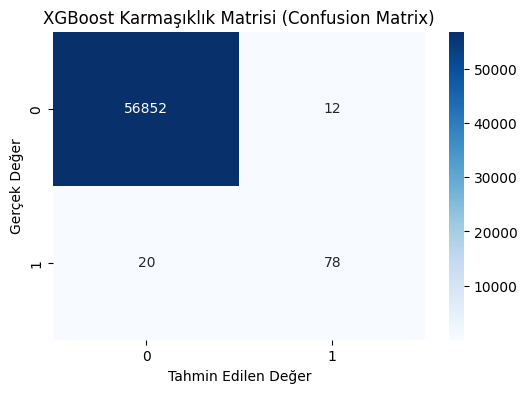

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veriyi Yükle
# (creditcard.csv dosyasının kodla aynı klasörde olduğundan emin ol)
df = pd.read_csv('creditcard.csv')

# 2. X ve y'yi ayır
X = df.drop('Class', axis=1)
y = df['Class']

# 3. Eğitim ve Test seti ayırımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Kural Tabanlı Sistem Simülasyonu (Sadece yüksek tutarlı işlemleri fraud sayan basit kural)
y_pred_rule = np.where((X_test['Amount'] > 500) & (X_test['V1'] < -3), 1, 0)

# 5. Random Forest Modeli Eğitimi
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 6. XGBoost Modeli Eğitimi
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 7. Sonuçları Görüntüle
print("--- KURAL TABANLI SİSTEM ---")
print(classification_report(y_test, y_pred_rule))

print("\n--- RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))

# 8. XGBoost için Confusion Matrix Çizimi (Bunu rapora koyabilirsin)
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin Edilen Değer')
plt.show()

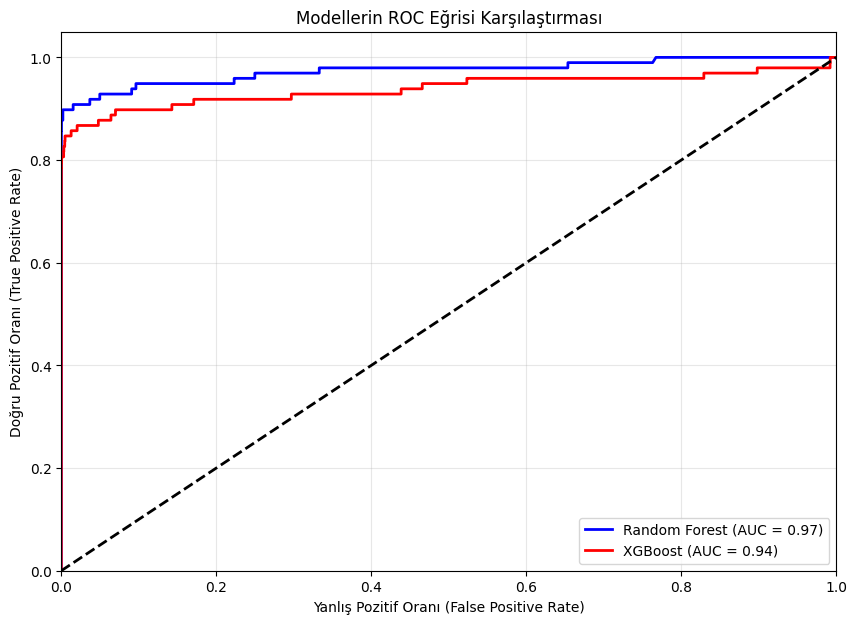

In [3]:
from sklearn.metrics import roc_curve, auc

# Tahmin olasılıklarını al (ROC eğrisi için olasılıklar gerekir)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# ROC değerlerini hesapla
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# AUC değerlerini hesapla
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Grafiği çiz
plt.figure(figsize=(10, 7))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='blue', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})', color='red', lw=2)

# Şans çizgisini ekle (0.5 noktası)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)')
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)')
plt.title('Modellerin ROC Eğrisi Karşılaştırması')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()